<a href="https://colab.research.google.com/github/mkywall/workshop-2026/blob/main/NSF_Summer_School_2026_Crucible_Session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Setup**

### Install the Crucible Python Client + Command Line Tool ([nano-crucible](https://pypi.org/project/nano-crucible/))

In [ ]:
%%capture
!pip install nano-crucible

In [ ]:
# import packages we will need
from pprint import pprint
import os
import yaml
import pandas as pd
import numpy as np
from crucible import CrucibleClient
from crucible.models import Dataset,Sample, Project

### Set up your access to the example data files

**If running in Google Colab:**
- Upload the example-data folder from GitHub to your Google Drive
- Mount the Google Shared Drive

In [ ]:
# only for colab users
from google.colab import drive
drive.mount('/content/drive')

Match the path below to the location where your data is saved

In [ ]:
# google drive:
data_path = '/content/drive/MyDrive/example-data'

# running locally:
data_path = './example-data'

In [ ]:
# Check that it seems correct - you should see the files listed below:
os.listdir(data_path)

## **2. Create a user account, get an API key, and connect to the client**

**Create a User Account**
*   Navigate to https://crucible.lbl.gov/explore in your browser
*   Sign in with your ORCID. This will generate a Crucible user account for you

**Get your API key**
* From the Crucible Explorer (https://crucible.lbl.gov/explore), navigate to your user profile in the top left corner



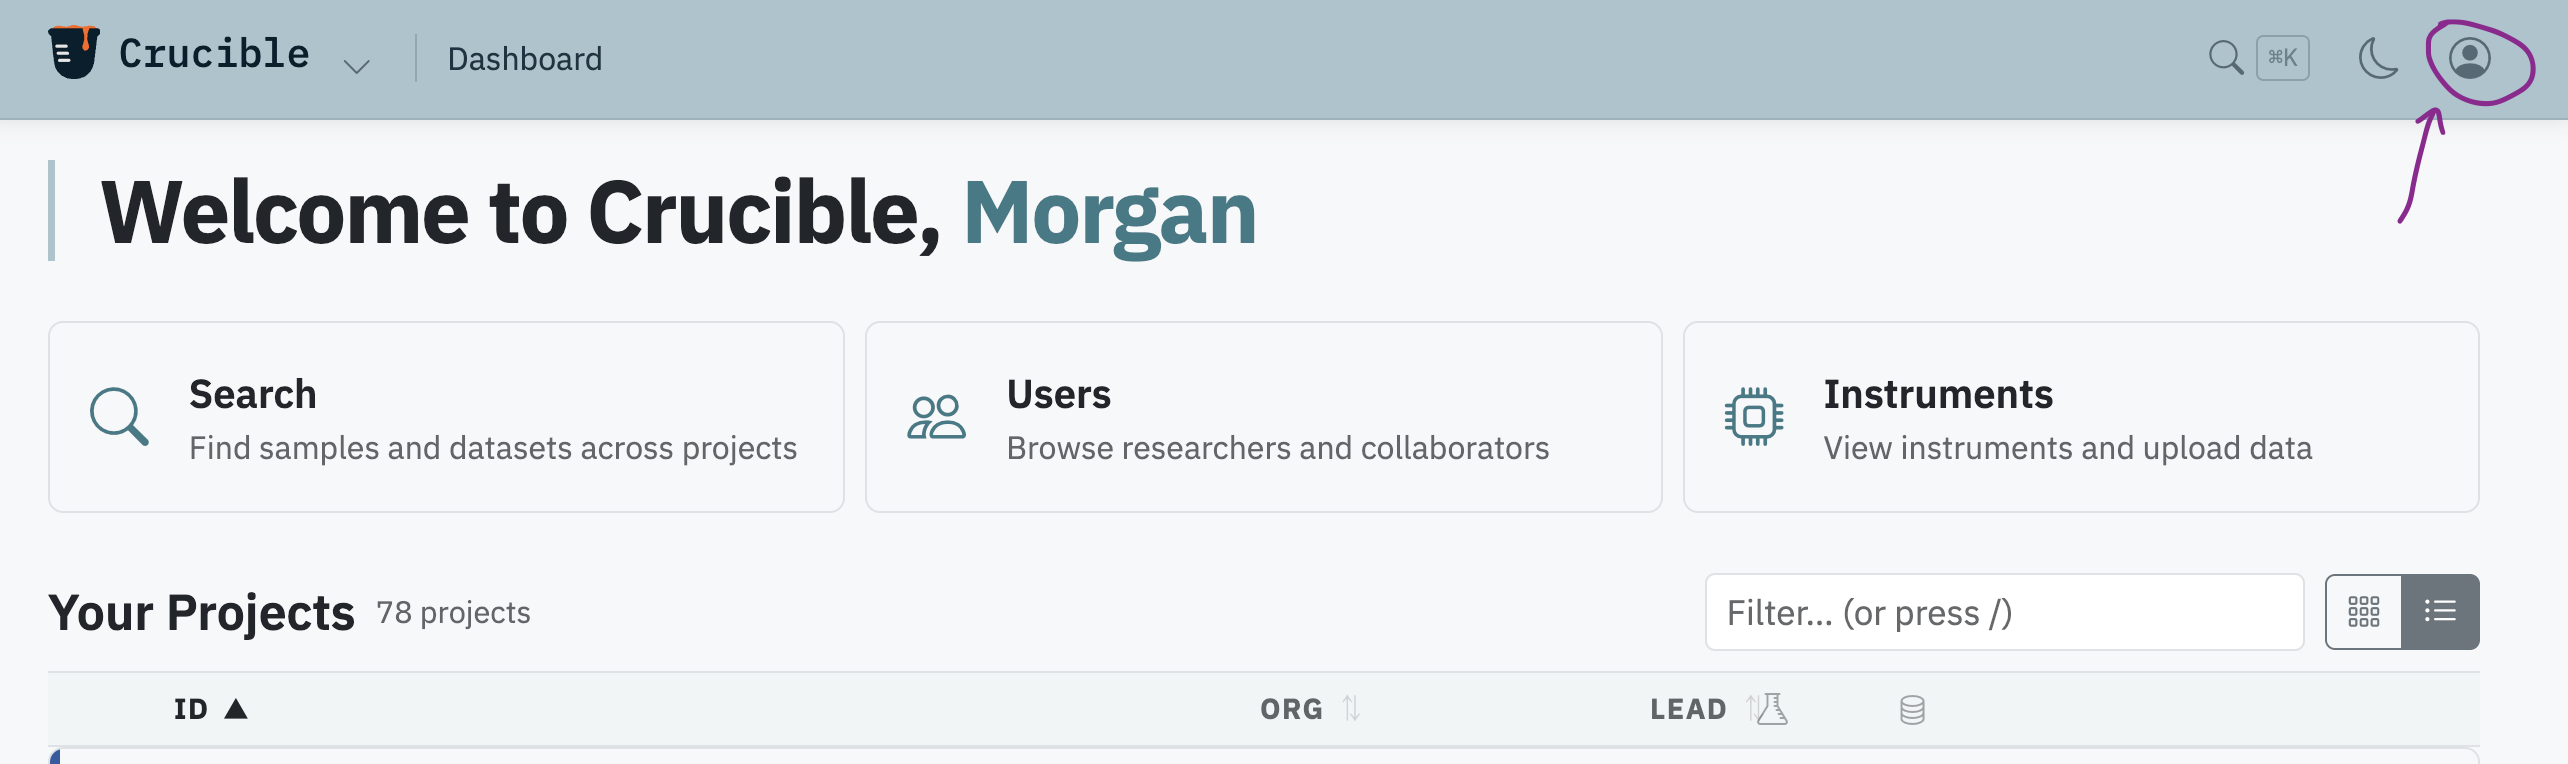

* Select "Show API key"
* Run the cell below and paste your API key into the password box

In [ ]:
from getpass import getpass
api_key = getpass('Enter your API key: ')

**Connect to the Crucible Client**

In [ ]:
from crucible import CrucibleClient
from crucible.models import Project, Sample, Dataset
client = CrucibleClient(api_url = 'https://crucible.lbl.gov/api/v2', api_key = api_key)

## **3. Crucible Basics: Creating Projects, Samples, and Datasets**

#### **Create a project**



A **project** is the top-level organizational unit. Projects commonly map to research projects or user facility proposals.

Projects serve two primary purposes:

* **Organization** — resources belong to a project, making them easier to find and filter.
* **Access control** — all members of a project can read the datasets and samples within it. Adding a user to a project grants them access to all associated data.

Creating a project involves two steps:

1. Create a Crucible `Project` instance to represent the project.
2. Pass the `Project` Python object to the `client.projects.create()` function.

<br>

If **the project ID does not already exist** the newly created project is returned.If the project already exists you will receive a 409 error and may use the Crucible Client to get that project information if you have access to the existing project.



```python
from crucible.models import Project
from crucible import CrucibleClient
client = CrucibleClient()

new_project = Project(
    project_id=<add-a-unique-project-id-here>,      # eg. proposal number MFP00000, or descriptive: alphafold_for_microelectronics
    organization=<add-your-institution-name-here>,  # eg. LBNL Molecular Foundry
    project_lead_email=<put-your-crucible-email-here>,  # eg. johndoe@lbl.gov
    title=<add-a-descriptive-title>,                 # optional, eg. Developing an AI-driven closed-loop platform for materials exploration and discovery
)

client.projects.create(new_project)
```

Additional details about Crucible Projects can be found [here](https://molecularfoundrycrucible.github.io/nano-crucible/user-guide/projects/)!

In [ ]:
# ========== Create your own project!
# ========== Fill in your information below and/or choose your own unique project_id

your_initials = ''
your_email = ''
your_organization = ''

smallid = int(1000*np.random.rand())

# Choose a Project ID
my_project_id = f'nsf-summer-school-2026-{your_initials}-{smallid}'

# Define a Project object
new_project = Project(project_id = my_project_id,
                      organization= your_organization,
                      project_lead_email= your_email,
                      title= f'NSF Summer School 2026 - {your_initials}')
try:
  # Create the project in Crucible
  proj = client.projects.create(new_project)
except:
  # Get the existing project if one already exists
  proj = client.projects.get(new_project.project_id)

pprint(proj)

#### **Create a sample in your project**



A **sample** represents a physical or computational material that data was collected from. Samples are useful for tracking provenance: which datasets were measured from which material, and how that material was prepared.

Samples support parent-child hierarchies. For example in a perovskite workflow, reagents, stock solutions, mixed precursor solutions, and deposited thin films can all be modeled as a parent-child sample chain to reflect the entire synthesis trajectory.

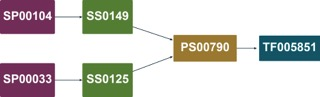


<br><br>

Currently, sample is also used broadly to include containers or batches of samples as well. A batch of 8 thin films prepared on a tray, may have child-parent relationships to the tray to reflect their shared connection to the `tray` sample.


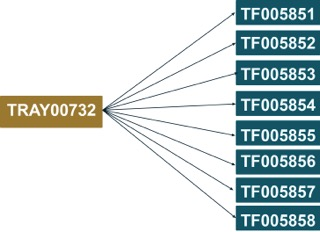

<br><br>
Datasets can be linked to one or more samples, and samples may be linked to one or more datasets.

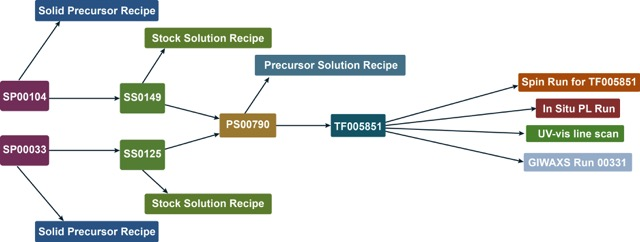

Creating a sample can be executed with the `client.samples.create()` function. The arguments match the attributes of the Sample model (use of the Sample model directly is planned for implementation).

Currently, sample names must be unique *within a project*. If the sample_name already exists within the given project, you will receive a 409 error and may either use the Crucible Client to get that sample or choose a unique name for your sample.

UUID's are assigned for samples on the server side by default, but may also be pregenerated and provided up front by the user. The [mfid python package](https://pypi.org/project/mfid/) can be used to generate Crucible compatible UUIDs.


```
# optional- generate your own mfid
import mfid
sample_uuid = mfid.mfid()[0]

# create a Sample
from crucible import CrucibleClient
client = CrucibleClient()

client.samples.create(
    unique_id = sample_uuid,
    sample_name=<choose-a-project-unique-sample-name>, # eg. TF00001
    sample_type=<user-defined-category>,  # eg. Chemical Reagent, Thin Film, Solution
    project_id=<the-project-id-you-used-above>,
    description=<open-field-describing-sample>, # optional, eg. manually prepared MAPbI₃ Perovskite Thin Film)
```

More information about working with samples can be found [here](https://molecularfoundrycrucible.github.io/nano-crucible/user-guide/samples/)!

In [ ]:
# Create the Sample in Crucible
sample_record = client.samples.create(sample_name = 'TF-TEST00001',
                      sample_type = 'Thin Film',
                      project_id = my_project_id,
                      description = 'test sample for the demo!')
pprint(sample_record)

#### **Create Datasets**


A **dataset** is the core data object in Crucible. It can combine:

- **Files** — the actual measurement data (optional).

- **Structured metadata** — general attributes collected about each dataset regardless of data type, such as *measurement*, *data_type*, *instrument_name*,  *timestamp*, and *data_format*. Other information such as *creation_time* and *modification_time* will be generated and recorded on the server side.

- **Scientific metadata** — free-form key-value pairs for experiment-specific parameters, notes, and comments that are considered necessary for reproducibility and provenance. The structure is intentionally flexible to accommodate a variety of use cases and reduce input burden for experimentalists as well as allow adaptability over time. However, it is recommended to standardize the structure of the scientific data for specific data types within a project or organization to promote higher quality data curation and enable downstream analytics.

- **Keywords** — searchable tags associated with each dataset

- **Thumbnails** - Small, low resolution images to represent the results or underlying data in the dataset.

Datasets can be linked to each other in parent-child relationships to represent processing pipelines (e.g., raw data → calibrated → analyzed) or collections of related data.

**A note about datasets**

In Crucible, the definition and requirements of what constitutes a dataset are intentionally left loose to be flexible enough to allow the wide variety of use cases needed in nanoscale research and materials science.  

Generally, **datasets** represent an experimental process or observation that has been performed to produce either a sample or a result.  

The sources of this information will vary widely across use cases, particularly with regard to how the information is captured and recorded.  Use cases range from datasets that may simply be collections of manually curated details (eg. a synthesis recipe) to instrument output files that include experimental parameters alongside results from a variety of software platforms and detectors (eg. 4D-STEM) that together provide all of the information required to reproduce the experiment.  To allow flexibility across these use cases, Dataset information can be provided entirely through the Crucible API as JSON, extracted from the files themselves during a server side ingestion process, or both.

Creating a dataset requires 2 steps:
1) Define the Dataset instance
2) Pass the Dataset object to client.datasets.create() along with any desired scientific metadata, files, and keywords

All of the fields described below are optional and can be updated after dataset record creation.  It is possible to create a dataset with simply: `new_dataset = Dataset()` in which case a unique_id will be assigned server-side and returned in the client response.
<br>

```python
from crucible.models import Dataset
from crucible import CrucibleClient
client = CrucibleClient()

new_dataset = Dataset(dataset_name = <human-readable-name>, # your choice, often chosen to match the file name
                      project_id = <project-id-of-dataset>, # members of this project will have access to this dataset
                      measurement = <industry-standard-general-experiment-type>, # eg. RGA, Raman Spectroscopy
                      data_type = <user-specific-data-acquisition-descriptor>, # eg. ScopeFoundry SV_Ramp Image Series
                      instrument_name = <crucible-name-of-instrument>, # eg. jupiter-afm
                      data_format = <primary-file-extension>, # eg. h5, csv, dm3
                      session_name = <tag-to-group-datasets-by>, # not relevant for all use cases
                      timestamp = <dataset-acquisition-time-isoformat>,
                      public = <true-or-false> # default: false
                      )
scientific_metadata = {} # user-defined key-value pairs
files_to_upload = [] # optional list of files that constitute the dataset
keywords = [] # optional tags for searching/grouping datasets

client.datasets.create(new_dataset,
                       scientific_metadata,
                       files_to_upload,
                       keywords)
```

More information about datasets is available [here](https://molecularfoundrycrucible.github.io/nano-crucible/user-guide/datasets/)!

**1. Upload a JSON dictionary as a dataset**

In [ ]:
# Define a Dataset object
json_only_dataset = Dataset(dataset_name = 'Precursor Solution Recipe - PS0001',
                            project_id = my_project_id,
                            measurement = 'Precursor Solution Synthesis Recipe',
                            data_type = 'manual_precursor_solution_synthesis',
                            instrument_name = None,
                            data_format = None,
                            timestamp = '20260701')

scientific_metadata = {"mixing_ratio": '1:1',
                        "notes": "filtered in air",
                        "operator": "Declan",
                        "preparation_method":"ManualMixing",
                        "smiles_metal_canonical": "I[Pb]I",
                        "smiles_organic_canonical": "C[NH3+].[I-]",
                        "storage_location": "FumeHood",
                        "target_concentration_(m)": 1.2,
                        "target_stoichiometry": "MAPbI\u2083"}

# Create the Dataset in Crucible
json_ds_record = client.datasets.create(dataset = json_only_dataset,
                                        scientific_metadata = scientific_metadata)
pprint(json_ds_record)

**2. Upload a file as a dataset and rely on server side parsing to extract metadata**

Example 1: TEM Data

In [ ]:
# Define a Dataset object
file_only_dataset  = Dataset(project_id = my_project_id, instrument_name = 'titanx')

files_to_upload = ['tem_diffraction_example.ser', 'tem_diffraction_example.emi']

# add the data path to each file
files_to_upload = [os.path.join(data_path, f) for f in files_to_upload]

# Create the Dataset in Crucible
file_ds_record = client.datasets.create(dataset = file_only_dataset,
                       files_to_upload = files_to_upload)
pprint(file_ds_record)

Example 2: UV-vis Spectroscopy Dataset

In [ ]:
# Define a Dataset object
file_only_dataset  = Dataset(project_id = my_project_id)

files_to_upload = ['uvvis_example_pollux_oospec_multipos_line_scan.h5']

# add the data path to each file
files_to_upload = [os.path.join(data_path, f) for f in files_to_upload]

# Create the Dataset in Crucible
file_ds_record = client.datasets.create(dataset = file_only_dataset,
                                        files_to_upload = files_to_upload)
pprint(file_ds_record)

**3. Upload a file with some JSON to provide additional metadata about your dataset**

In [ ]:
# Define a Dataset object
hybrid_dataset = Dataset(dataset_name = 'Carrier Image Batch 003 + 004',
                         project_id = my_project_id,
                         measurement = 'image',
                         data_type = 'thin_film_nikon_carrier_image',
                         instrument_name = 'photobox',
                         data_format = 'jpg')

scientific_metadata = {'x_resolution': 300,
                       'y_resolution': 300,
                       'resolution_unit': 'inch',
                       'exposure_time(s)': 0.1,
                       'focal_length(mm)': 35}

image_file = os.path.join(data_path, 'carrier_image_example.jpg')
files_to_upload = [image_file]

# Create the Dataset in Crucible
hybrid_ds_record = client.datasets.create(dataset = hybrid_dataset,
                                          files_to_upload = files_to_upload,
                                          scientific_metadata = scientific_metadata)

pprint(hybrid_ds_record)

#### **Create a relationship between your sample and your dataset**

In [ ]:
sample_id = sample_record['unique_id']
dataset_id = hybrid_ds_record['dsid'] # can repeat with the other dataset IDs as well

# Create the relationship
client.datasets.add_sample(dataset_id, sample_id)

**Check out what you created**

Navigate to https://crucible.lbl.gov/explore



*   Find your project
*   Browse the project to explore your new sample and datasets
*   View the thumbnails
*   Check out the Scientific Metadata
*   Confirm the files and ingestion status
*   Explore the data in a Data Viewer








## **4. Using relationships to track Sample histories throughout an experimental workflow**

In this section, we will create samples and datasets to represent a synthesis workflow.  Feel free to adapt this section to your own workflow if desired or use the example provided. For our example, links to user interfaces that can be used to facilitate the process are included alongside the python functions as alternatives.

**Example**: Perovskite Thin Film synthesis involves a series of experimental steps that can affect the resulting performance and characteristics. Below is an example of a potential Perovskite workflow and the data that we would try to capture at each stage of the process.

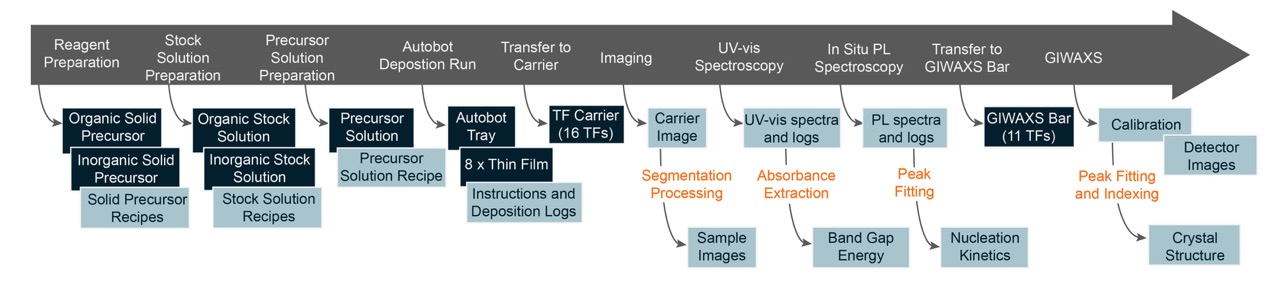

#### **Step 1: Reagant Preparation**


- Create 2 solid precursor samples
- For each:
  - Create a dataset to capture the synthesis details
  - Link the the dataset to the sample

  <br>

**Two options**:
1) Run the code below
2) Navigate to one of our custom [web apps](https://perovskite-synthesis-ui-main-776258882599.us-central1.run.app) to enter the information and populate the backend database. You can copy and paste the sample information from the Solid Precursor CSV file.

In [ ]:
# Define a function that executes the steps for each Solid Precursor

def add_precursor_info(sample_details, dataset, synthesis_details):

  # create the sample
  sample_record = client.samples.create(**sample_details)

  # create the dataset
  dataset_record = client.datasets.create(dataset,
                                          scientific_metadata = synthesis_details)

  # link the sample to the dataset
  client.datasets.add_sample(dataset_record['dsid'],
                             sample_record['unique_id'])

  return sample_record, dataset_record

In [ ]:
# Solid Precursor 1
synthesis_details = {'abbrev': 'MAI',
                     'cas': None,
                     'smiles': 'C[NH3+].[I-]',
                     'name': 'methylammonium iodide',
                     'opened_timestamp': '20251020',
                     'rfid': None,
                     'storage_location': '6207 Bench',
                     'vendor': 'Homemade'}

sample_details = {'sample_name': "SP0001",
                  'sample_type': 'solid precursor',
                  'description' :'organic precursor for perovskite synthesis',
                  'project_id': my_project_id}

dataset_info = Dataset(dataset_name = 'Solid Precursor Details SP0001', measurement = 'Solid Precursor Synthesis Recipe', data_type = 'solid precursor synthesis', project_id = my_project_id)

solid_precursor_1, sp1_synthesis = add_precursor_info(sample_details, dataset_info, synthesis_details)


In [ ]:
# Solid Precursor 2
synthesis_details =  {'abbrev': 'PbI2',
                     'cas': '10101-63-0',
                     'smiles': 'I[Pb]I',
                     'name': 'lead(II) iodide',
                     'opened_timestamp': '20251020',
                     'rfid': None,
                     'storage_location': '6207 Bench',
                     'vendor': 'Sigma-Aldrich'}

sample_details = {
    'sample_name': "SP0002",
    'sample_type': 'solid precursor',
    'description' :'metal precursor for perovskite synthesis',
    'project_id': my_project_id}

dataset_info = Dataset(dataset_name = 'Solid Precursor Details SP0006', measurement = 'Solid Precursor Synthesis Recipe', data_type = 'solid precursor synthesis', project_id = my_project_id)

solid_precursor_2, sp2_synthesis = add_precursor_info(sample_details, dataset_info, synthesis_details)

#### **Step 2: Stock Solution Preparation**


- Create 2 stock solution samples
- For each:
  - Create a dataset to capture the preparation details
  - Link the dataset to the sample
  - Link to the solid_precursor sample used

  <br>

**Two options**:
1) Run the code below
2) Navigate to one of our custom [web apps](https://perovskite-synthesis-ui-main-776258882599.us-central1.run.app) to enter the information and populate the backend database. You can copy and paste the sample information from the Stock Solution CSV file.

In [ ]:
# Define a function that executes the steps for each Stock Solution
def add_stock_solution_info(sample_details, dataset, synthesis_details, precursor_sample):

  # create the sample
  sample_record = client.samples.create(**sample_details)

  # create the dataset
  dataset_record = client.datasets.create(dataset,
                                          scientific_metadata = synthesis_details)

  # link the sample to the dataset
  client.datasets.add_sample(dataset_record['dsid'],
                             sample_record['unique_id'])

  # link the sample to its precursor
  client.samples.link(parent_id = precursor_sample['unique_id'],
                      child_id = sample_record['unique_id'])

  return sample_record, dataset_record

In [ ]:
# Stock Solution 1 (organic component)
synthesis_details = {'metal_cation_actual_weight_mg': None,
                     'metal_salt_name': None,
                     'metal_salt_sp-id': None,
                     'notes': 'excellent solubility',
                     'operator': 'Declan',
                     'organic_cation_actual_weight_mg': 239.91,
                     'organic_salt_name': 'MAI',
                     'organic_salt_sp-id': 'SP0001',
                     'sample_description': None,
                     'sample_name': 'SS0001',
                     'solvent': 'DMF',
                     'solvent_volume_ml': 1.006,
                     'storage_location': None,
                     'target_concentration_mol': 0.9,
                     'timestamp': '20251209'}
sample_details = {
    'sample_name': "SS0001",
    'sample_type': 'stock solution',
    'project_id': my_project_id}

dataset_info = Dataset(dataset_name = 'Stock Solution Details SS0001', measurement = 'Stock Solution Synthesis Recipe', data_type = 'stock solution synthesis', project_id = my_project_id)

stock_solution_1, ss1_synthesis_ds = add_stock_solution_info(sample_details, dataset_info, synthesis_details, solid_precursor_1)


In [ ]:
# Stock Solution 2 (metal component)
synthesis_details = {'metal_cation_actual_weight_mg': None,
                     'metal_salt_name': 'PbI2',
                     'metal_salt_sp-id': 'SP0002',
                     'notes': 'excellent solubility',
                     'operator': 'Declan',
                     'organic_cation_actual_weight_mg': None,
                     'organic_salt_name': None,
                     'organic_salt_sp-id': None,
                     'sample_description': None,
                     'sample_name': 'SS0002',
                     'solvent': 'DMF',
                     'solvent_volume_ml': None,
                     'storage_location': None,
                     'target_concentration_mol': None,
                     'timestamp': '20251209'}
sample_details = {
    'sample_name': "SS0002",
    'sample_type': 'stock solution',
    'project_id': my_project_id}

dataset_info = Dataset(dataset_name = 'Stock Solution Details SS0002', measurement = 'Stock Solution Synthesis Recipe', data_type = 'stock solution synthesis', project_id = my_project_id)

stock_solution_2, ss2_synthesis = add_stock_solution_info(sample_details, dataset_info, synthesis_details, solid_precursor_2)

#### **Step 3: Precursor Solution Preparation**


- Create a precursor solution sample
- Create a dataset to capture the preparation details
  - Link the dataset to the sample
  - Link the precursor to the stock solutions used

  <br>

**Two options**:
1) Run the code below
2) Navigate to one of our custom [web apps](https://perovskite-synthesis-ui-main-776258882599.us-central1.run.app) to enter the information and populate the backend database.

In [ ]:
# Create the Sample
precursor_solution = client.samples.create(sample_name = 'PS0001',
                                           sample_type = 'precursor solution',
                                           project_id = my_project_id)

# Define and create the dataset
'''
We actually already did this in Section 3.
We can use the Precursor Solution Dataset that we created previously,
but now we will link it to the precursor sample we just created.
'''

precursor_synthesis_dsid = json_ds_record['dsid']

# Link the dataset to the sample
client.datasets.add_sample(precursor_synthesis_dsid,
                           precursor_solution['unique_id'])

# Link the precursor to each stock solution
for stock_solution in stock_solution_1, stock_solution_2:
  client.samples.link(parent_id = stock_solution['unique_id'],
                      child_id = precursor_solution['unique_id'])


#### **Step 4: Thin Film Deposition**

Thin Film Deposition runs on an automated robot that accepts user defined input recipes and outputs a log file of the performed actions and experimental parameters. <br><br>We will upload the input and output files from the instrument and rely on an automated server-side data parser to:
* Extract the scientific metadata
* Create the necessary relationships between the samples on the run and the deposition dataset.

In [ ]:

# The autobot creates a unique ID for the dataset at run time, so we will parse that and pass it in at the time of dataset creation
autobot_file = os.path.join(data_path, 'autobot_output_example.yaml')
with open(autobot_file, 'r') as f:
  parsed_run_id = yaml.safe_load(f).get('run_id')
  print(parsed_run_id)

# Define the Dataset object
autobot_dataset  = Dataset(unique_id = parsed_run_id,
                         dataset_name = 'Autobot Spin Run Batch 004',
                         project_id = my_project_id,
                         measurement = 'thin_film_deposition',
                         data_type = 'autobot_spin_run',
                         instrument_name = 'spinbot',
                         data_format = 'yaml')
# List the files
files_to_upload = ['autobot_input_example.yaml',
                   'autobot_output_example.yaml',
                   'autobot_log_example.yaml']

files_to_upload = [os.path.join(data_path, f) for f in files_to_upload]

# Create the Dataset in Crucible
autobot_ds_record = client.datasets.create(dataset = autobot_dataset, files_to_upload = files_to_upload)
pprint(autobot_ds_record)

In [ ]:
# === Check the status of the automated data parsing
client.ingestions.list(autobot_ds_record['dsid'])

In [ ]:
# === See what thin films were created during the run

# Get the dataset ID
dsid = autobot_ds_record['unique_id']

# List samples filtered on having a relationship with that Dataset
thinfilm_samples = client.samples.list(dataset_id = dsid)

# check them out
pprint(thinfilm_samples)

## **5. Share your data with other users**

#### **Add a user to your project**

Members of a project can add other users to their projects to collaboratively share results from different experiments or facilities.

In [ ]:
client.projects.add_user(project_id = my_project_id, # The project you want to share
                         orcid = '') # The other person's ORCID

#### **Request a Downloadable Link for the Data Files**

Links expire after 30 minutes and can only be **generated** by authorized users, but can be shared with anyone prior to their expiration.

In [ ]:
client.datasets.get_download_links(uvvis_ds_record['unique_id'])

**Find and copy the shareable link through the website**



*   Navigate to https://crucible.lbl.gov/explore
*   Click on your project
*   Select a dataset
*   Scroll to the bottom
*   Under files you can find a button for the shareable link



